# Direct Air Capture (DAC) Solid Sorbent Model

## Overview
This notebook implements a high-fidelity numerical simulation model for a solid-sorbent Direct Air Capture (DAC) system. 

The module evaluates the mass flow rate of captured carbon dioxide, calculates the mechanical fan power required to pull ambient air through the contactor channels, and tracks the low-temperature thermal energy necessary to desorb and isolate pure $\text{CO}_2$ gas during the regeneration stage.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: Scientific Infrastructure Loaded Natively ---")

--- Cell 1: Scientific Infrastructure Loaded Natively ---


# 1. Component Boundaries & Ambient Real-Time Inputs
Initializes the contactor design variables, sorbent capture metrics, specific energy consumption keys, and the diurnal ambient temperature variations.

In [6]:
# =============================================================================
# 1. INPUT PARAMETERS & CAPTURE SPECIFICATIONS (SI UNITS)
# =============================================================================

# ---------- Contactor & Air Stream Design Parameters ----------
V_dot_air_nominal = 150.0          # Nominal air volumetric flow rate through contactor [m³/s]
C_CO2_ppm         = 420.0          # Atmospheric CO2 concentration concentration [ppm]
eta_capture       = 0.75           # CO2 capture efficiency of the sorbent bed [-]
Delta_P_bed       = 120.0          # Contactor bed pressure drop [Pa]
eta_fan           = 0.78           # Mechanical efficiency of the air intake fans [-]

# ---------- Specific Energy Consumption Targets ----------
SEC_thermal       = 2.50 * 1e9     # Specific thermal energy for regeneration [J per metric ton of CO2] (2.5 GJ/t)
SEC_electrical    = 0.25 * 1e9     # Specific auxiliary electrical load [J per metric ton of CO2] (0.25 GJ/t)

# ---------- Ambient Coordinates & Air Gas Constants ----------
R_air             = 287.05         # Specific gas constant for air [J/kg-K]
P_atm             = 101325.0       # Atmospheric operating pressure [Pa]
rho_CO2_pure      = 1.842          # Density of pure CO2 at nominal states [kg/m³]

# Diurnal Ambient Temperature Profile (24 Hours)
T_amb_profile = np.array([
    15, 14, 14, 13, 13, 14, 16, 18, 21, 23, 25, 26, 27, 27, 26, 25, 23, 21, 19, 18, 17, 16, 16, 15
]) + 273.15

print("--- Cell 2: DAC System Operational Inputs Configured ---")

--- Cell 2: DAC System Operational Inputs Configured ---


# 2. Governing Mass and Energy Balancing Equations
Evaluates the real-time air density shifts, mass collection rates, fluid work requirements, and thermal desorption profiles hour-by-hour across the diurnal cycle.

In [7]:
# =============================================================================
# 2. DIURNAL SIMULATION MATRIX CALCULATIONS
# =============================================================================

dac_history_log = []

for hour in range(24):
    T_ambient = T_amb_profile[hour]
    
    # 1. Evaluate real-time air density based on ambient temperature variations
    rho_air = P_atm / (R_air * T_ambient)
    m_dot_air = V_dot_air_nominal * rho_air  # Net mass flow rate of air [kg/s]
    
    # 2. Convert CO2 parts per million (ppm) to mass fraction values
    # Mass fraction ≈ ppm * (Molar Mass of CO2 / Molar Mass of Air) * 1e-6
    w_CO2 = C_CO2_ppm * (44.01 / 28.97) * 1e-6
    
    # 3. Mass Balance: Calculate CO2 capture yield rate [kg/s]
    m_dot_CO2_captured = m_dot_air * w_CO2 * eta_capture
    m_dot_CO2_ton_hr   = (m_dot_CO2_captured * 3600.0) / 1000.0  # Convert to metric tons per hour
    
    # 4. Fluid Dynamics: Mechanical Fan Power Consumption [W]
    # Power = (Volumetric Flow * Pressure Drop) / Fan Efficiency
    W_dot_fan = (V_dot_air_nominal * Delta_P_bed) / eta_fan
    
    # 5. Energy Balances: Thermal and Auxiliary Electrical Power Loads [W]
    Q_dot_thermal_DAC = m_dot_CO2_captured * (SEC_thermal / 1000.0)
    W_dot_aux_DAC     = m_dot_CO2_captured * (SEC_electrical / 1000.0)
    
    # Net cumulative electrical load [kW]
    W_dot_electrical_total_kW = (W_dot_fan + W_dot_aux_DAC) / 1000.0
    Q_dot_thermal_DAC_kW      = Q_dot_thermal_DAC / 1000.0
    
    # Save step indicators to timeline logs
    dac_history_log.append({
        'Hour': hour + 1,
        'Air Density [kg/m³]': rho_air,
        'CO2 Captured [kg/h]': m_dot_CO2_ton_hr * 1000.0,
        'Fan Power [kW]': W_dot_fan / 1000.0,
        'Total Elec Power [kW]': W_dot_electrical_total_kW,
        'Thermal Load [kW]': Q_dot_thermal_DAC_kW
    })

df_dac_results = pd.DataFrame(dac_history_log)
display(df_dac_results.iloc[8:17])  # Display core daytime operations

,Hour,Air Density [kg/m³],CO2 Captured [kg/h],Fan Power [kW],Total Elec Power [kW],Thermal Load [kW]
8,9,1.200025,310.096879,23.076923,44.611429,215.345055
9,10,1.191921,308.002691,23.076923,44.465999,213.890758
10,11,1.183925,305.936599,23.076923,44.322520,212.455972
11,12,1.179968,304.913913,23.076923,44.251500,211.745773
12,13,1.176036,303.898041,23.076923,44.180954,211.040306
13,14,1.176036,303.898041,23.076923,44.180954,211.040306
14,15,1.179968,304.913913,23.076923,44.251500,211.745773
15,16,1.183925,305.936599,23.076923,44.322520,212.455972
16,17,1.191921,308.002691,23.076923,44.465999,213.890758


# 3. High-Resolution Performance Graphics & Key Verification Report
Renders daily captured mass accumulation curves alongside your structured system validation console report.

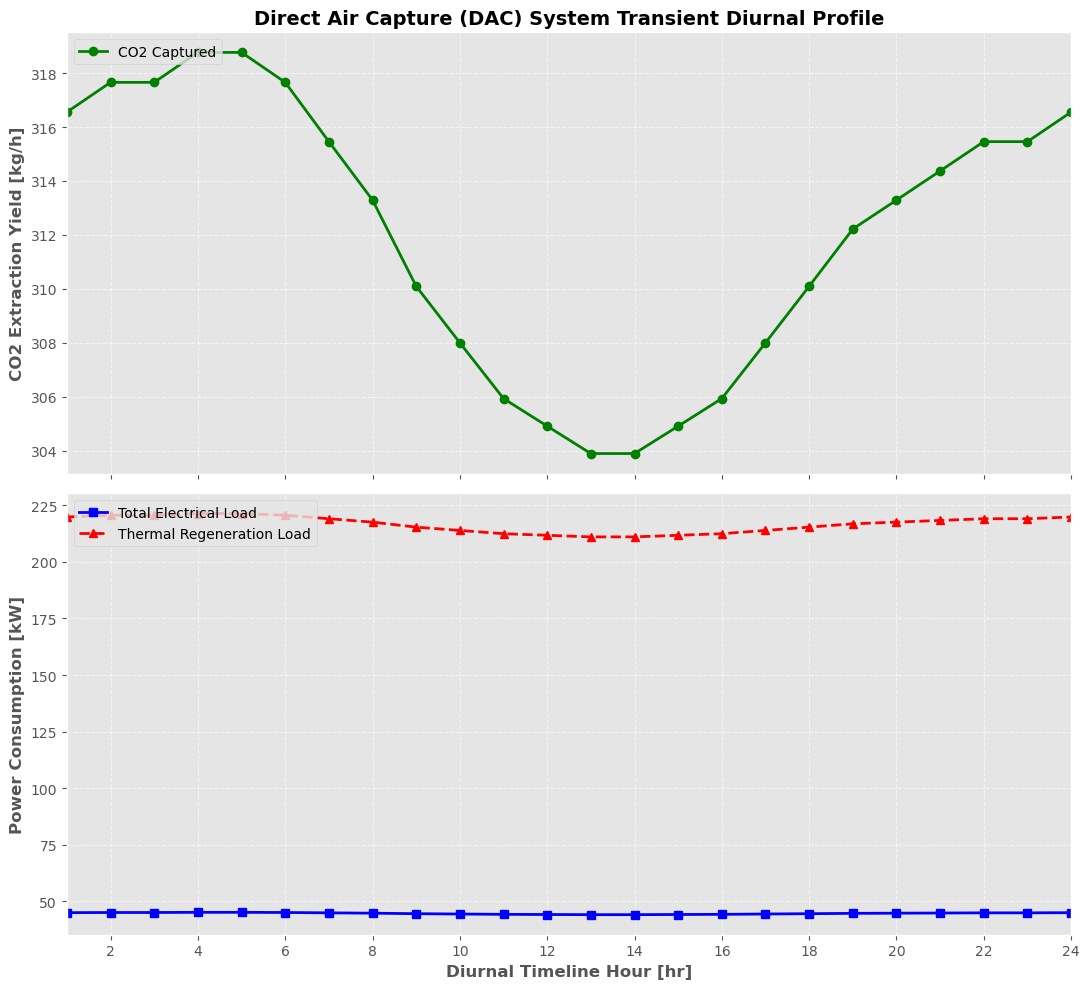

     DAC FIELD CONVERGENCE PERFORMANCE SUMMARY    
Contactor Airflow Capacity     : 150.0 m³/s
Atmospheric CO2 Baseline Design: 420.0 ppm
--------------------------------------------------
Net Daily Carbon Dioxide Yield : 7488.859 kg/day
Total Daily Electrical Demand  : 1073.91 kWh/day
Total Daily Thermal Input Demand: 5200.60 kWh/day
--------------------------------------------------
Baseline Fixed Fan Power Load  : 23.08 kW
Peak Hourly CO2 Capture Rate   : 318.77 kg/h


In [ ]:
# =============================================================================
# 3. VISUALIZATIONS & CONSOLE PERFORMANCE REPORTER
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Plot 1: Hourly CO2 Capture Performance Yield Tracking
ax1.plot(df_dac_results['Hour'], df_dac_results['CO2 Captured [kg/h]'], 'g-o', linewidth=2.0, label='CO2 Captured')
ax1.set_ylabel('CO2 Extraction Yield [kg/h]', fontweight='bold', fontsize=12)
ax1.set_title('Direct Air Capture (DAC) System Transient Diurnal Profile', fontweight='bold', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: Energetic Power Consumption Demands
ax2.plot(df_dac_results['Hour'], df_dac_results['Total Elec Power [kW]'], 'b-s', linewidth=2.0, label='Total Electrical Load')
ax2.plot(df_dac_results['Hour'], df_dac_results['Thermal Load [kW]'], 'r--^', linewidth=2.0, label='Thermal Regeneration Load')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('Power Consumption [kW]', fontweight='bold', fontsize=12)
ax2.set_xlim([1, 24]); ax2.set_xticks(range(2, 25, 2))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ---------- Extract Key Aggregated Portfolio Totals ----------
total_daily_CO2_captured_kg = df_dac_results['CO2 Captured [kg/h]'].sum()
total_daily_elec_kWh        = df_dac_results['Total Elec Power [kW]'].sum()
total_daily_thermal_kWh     = df_dac_results['Thermal Load [kW]'].sum()

# =============================================================================
# 4. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     DAC FIELD CONVERGENCE PERFORMANCE SUMMARY    ")
print(f"==================================================")
print(f"Contactor Airflow Capacity     : {V_dot_air_nominal:.1f} m³/s")
print(f"Atmospheric CO2 Baseline Design: {C_CO2_ppm:.1f} ppm")
print(f"--------------------------------------------------")
print(f"Net Daily Carbon Dioxide Yield : {total_daily_CO2_captured_kg:.3f} kg/day")
print(f"Total Daily Electrical Demand  : {total_daily_elec_kWh:.2f} kWh/day")
print(f"Total Daily Thermal Input Demand: {total_daily_thermal_kWh:.2f} kWh/day")
print(f"--------------------------------------------------")
print(f"Baseline Fixed Fan Power Load  : {df_dac_results['Fan Power [kW]'].iloc[0]:.2f} kW")
print(f"Peak Hourly CO2 Capture Rate   : {df_dac_results['CO2 Captured [kg/h]'].max():.2f} kg/h")
print(f"==================================================")